# Problem 4 - Grover Search with Dynamic MCZ

This notebook builds and runs Grover search using a measurement-uncompute multi-controlled Z (MCZ). It contains only the MCZ implementation needed by Grover, the phase oracle, the diffuser, and a runnable experiment.

For `k >= 3`, the dynamic MCZ computes a balanced AND tree, applies `Z` to its root, and removes the work ancillas using X-basis measurements and conditional CZ corrections.

In [28]:
from __future__ import annotations

import math
from typing import Iterable

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.result import marginal_counts
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    ReadoutError,
    depolarizing_error,
    pauli_error,
)

SEED = 1234
DEFAULT_SHOTS = 1024

print("Dynamic-MCZ Grover setup ready.")

Dynamic-MCZ Grover setup ready.


## Dynamic MCZ

Leaves of the balanced AND tree are the data qubits. Internal nodes use `k - 1` work ancillas. After the root phase is applied, each work qubit is measured in the X basis and its measurement result controls a CZ correction on its two inputs.

In [29]:
def validate_num_controls(num_controls: int) -> int:
    num_controls = int(num_controls)
    if num_controls < 1:
        raise ValueError("num_controls must be at least 1.")
    return num_controls


def mcz_ancilla_count(num_controls: int) -> int:
    """Number of balanced-AND-tree work ancillas."""
    num_controls = validate_num_controls(num_controls)
    return 0 if num_controls <= 2 else num_controls - 1


def balanced_and_tree(num_controls: int) -> dict:
    """Return bottom-up AND-tree levels in a logical qubit index space."""
    num_controls = validate_num_controls(num_controls)
    if num_controls <= 2:
        return {
            "levels": [],
            "root": 0 if num_controls == 1 else None,
            "ancilla_count": 0,
        }

    levels = []
    next_ancilla = 0
    current = list(range(num_controls))

    while len(current) > 1:
        level = []
        next_nodes = []
        index = 0

        while index < len(current):
            left = current[index]
            if index + 1 == len(current):
                next_nodes.append(left)
                index += 1
                continue

            right = current[index + 1]
            target = num_controls + next_ancilla
            next_ancilla += 1
            level.append((left, right, target))
            next_nodes.append(target)
            index += 2

        levels.append(level)
        current = next_nodes

    return {
        "levels": levels,
        "root": current[0],
        "ancilla_count": next_ancilla,
    }


def _as_list(register_or_qubits) -> list:
    return list(register_or_qubits) if register_or_qubits is not None else []


def apply_dynamic_mcz(
    qc: QuantumCircuit,
    controls,
    ancillas=None,
    measure_bits=None,
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Apply MCZ using forward AND computation and measurement-uncompute."""
    controls = _as_list(controls)
    ancillas = _as_list(ancillas)
    measure_bits = _as_list(measure_bits)
    num_controls = validate_num_controls(len(controls))

    if num_controls == 1:
        qc.z(controls[0])
        return qc
    if num_controls == 2:
        qc.cz(controls[0], controls[1])
        return qc

    tree = balanced_and_tree(num_controls)
    expected_ancillas = tree["ancilla_count"]
    if len(ancillas) != expected_ancillas:
        raise ValueError(
            f"Expected {expected_ancillas} ancillas, got {len(ancillas)}."
        )
    if len(measure_bits) != expected_ancillas:
        raise ValueError(
            f"Expected {expected_ancillas} measurement bits, got {len(measure_bits)}."
        )

    qubit_map = controls + ancillas

    for level in tree["levels"]:
        for left, right, target in level:
            qc.ccx(qubit_map[left], qubit_map[right], qubit_map[target])

    if add_barriers:
        qc.barrier()
    qc.z(qubit_map[tree["root"]])
    if add_barriers:
        qc.barrier()

    bit_index = 0
    for level in reversed(tree["levels"]):
        measured_nodes = []

        for left, right, target in level:
            bit = measure_bits[bit_index]
            qc.h(qubit_map[target])
            qc.measure(qubit_map[target], bit)
            measured_nodes.append((left, right, bit))
            bit_index += 1

        for left, right, bit in measured_nodes:
            with qc.if_test((bit, 1)):
                qc.cz(qubit_map[left], qubit_map[right])

        if add_barriers:
            qc.barrier()

    return qc

## Unitary and Dynamic MCZ Implementations

The unitary MCZ computes and reverses the AND tree. The dynamic MCZ replaces the reverse tree with X-basis measurements and conditional CZ corrections. These builders are used by the Grover oracle circuits below.

In [30]:
def apply_unitary_mcz(
    qc: QuantumCircuit,
    controls,
    ancillas=None,
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Apply a clean unitary MCZ using a reversible AND tree."""
    controls = _as_list(controls)
    ancillas = _as_list(ancillas)
    num_controls = validate_num_controls(len(controls))

    if num_controls == 1:
        qc.z(controls[0])
        return qc
    if num_controls == 2:
        qc.cz(controls[0], controls[1])
        return qc

    tree = balanced_and_tree(num_controls)
    expected_ancillas = tree["ancilla_count"]
    if len(ancillas) != expected_ancillas:
        raise ValueError(
            f"Expected {expected_ancillas} ancillas, got {len(ancillas)}."
        )

    qubit_map = controls + ancillas
    for level in tree["levels"]:
        for left, right, target in level:
            qc.ccx(qubit_map[left], qubit_map[right], qubit_map[target])

    if add_barriers:
        qc.barrier()
    qc.z(qubit_map[tree["root"]])
    if add_barriers:
        qc.barrier()

    for level in reversed(tree["levels"]):
        for left, right, target in reversed(level):
            qc.ccx(qubit_map[left], qubit_map[right], qubit_map[target])

    return qc


def build_unitary_mcz(
    num_controls: int,
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Build a standalone unitary MCZ circuit."""
    num_controls = validate_num_controls(num_controls)
    ancilla_count = mcz_ancilla_count(num_controls)
    data = QuantumRegister(num_controls, "data")
    anc = QuantumRegister(ancilla_count, "and") if ancilla_count else None
    registers = [data] + ([anc] if anc is not None else [])
    qc = QuantumCircuit(*registers, name=f"unitary_mcz_{num_controls}")
    apply_unitary_mcz(qc, data, anc or [], add_barriers=add_barriers)
    return qc


def build_dynamic_mcz(
    num_controls: int,
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Build a standalone measurement-uncompute MCZ circuit."""
    num_controls = validate_num_controls(num_controls)
    ancilla_count = mcz_ancilla_count(num_controls)
    data = QuantumRegister(num_controls, "data")
    anc = QuantumRegister(ancilla_count, "and") if ancilla_count else None
    mu = ClassicalRegister(ancilla_count, "mu") if ancilla_count else None
    registers = (
        [data]
        + ([anc] if anc is not None else [])
        + ([mu] if mu is not None else [])
    )
    qc = QuantumCircuit(*registers, name=f"dynamic_mcz_{num_controls}")
    apply_dynamic_mcz(
        qc,
        data,
        anc or [],
        mu or [],
        add_barriers=add_barriers,
    )
    return qc

In [31]:
# The standalone MCZ builders are available as:
# build_unitary_mcz(num_controls) and build_dynamic_mcz(num_controls).

## Grover Phase Oracle

For each marked state, `X` gates turn its zero bits into open controls, and the dynamic MCZ flips only that state's phase. Qiskit displays bit strings as `q[n-1]...q[0]`, so the target string is reversed when it is mapped to data-qubit indices.

Measurement-uncompute disentangles the work ancillas but does not necessarily leave them in `|0>`. The oracle therefore resets the workspace after each MCZ before it is reused.

In [32]:
def _normalize_marked_states(marked_states: str | Iterable[str]) -> list[str]:
    """Validate marked states and remove duplicate strings."""
    if isinstance(marked_states, str):
        marked_states = [marked_states]
    else:
        marked_states = list(marked_states)

    if not marked_states:
        raise ValueError("marked_states must contain at least one bit string.")
    if any(not isinstance(state, str) or not state for state in marked_states):
        raise ValueError("Every marked state must be a non-empty bit string.")

    num_qubits = len(marked_states[0])
    if any(len(state) != num_qubits for state in marked_states):
        raise ValueError("All marked states must have the same number of bits.")
    if any(set(state) - {"0", "1"} for state in marked_states):
        raise ValueError("Marked states may contain only '0' and '1'.")

    return list(dict.fromkeys(marked_states))


def apply_dynamic_grover_oracle(
    qc: QuantumCircuit,
    data,
    ancillas,
    measure_bits,
    marked_states: str | Iterable[str],
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Apply a multi-target Grover phase oracle using the dynamic MCZ."""
    marked_states = _normalize_marked_states(marked_states)
    data = _as_list(data)
    ancillas = _as_list(ancillas)
    measure_bits = _as_list(measure_bits)
    num_qubits = len(marked_states[0])
    ancilla_count = mcz_ancilla_count(num_qubits)

    if len(data) != num_qubits:
        raise ValueError(f"Expected {num_qubits} data qubits, got {len(data)}.")
    if len(ancillas) != ancilla_count:
        raise ValueError(f"Expected {ancilla_count} ancillas, got {len(ancillas)}.")
    if len(measure_bits) != ancilla_count:
        raise ValueError(
            f"Expected {ancilla_count} measurement bits, got {len(measure_bits)}."
        )

    for target in marked_states:
        zero_indices = [
            index for index, bit in enumerate(target[::-1]) if bit == "0"
        ]

        if zero_indices:
            qc.x([data[index] for index in zero_indices])

        apply_dynamic_mcz(
            qc,
            data,
            ancillas,
            measure_bits,
            add_barriers=add_barriers,
        )

        if zero_indices:
            qc.x([data[index] for index in zero_indices])
        if ancillas:
            qc.reset(ancillas)
        if add_barriers:
            qc.barrier(*data)

    return qc


def grover_oracle(
    marked_states: str | Iterable[str],
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Build a standalone dynamic-circuit Grover phase oracle."""
    marked_states = _normalize_marked_states(marked_states)
    num_qubits = len(marked_states[0])
    ancilla_count = mcz_ancilla_count(num_qubits)

    data = QuantumRegister(num_qubits, "data")
    anc = QuantumRegister(ancilla_count, "and") if ancilla_count else None
    mu = ClassicalRegister(ancilla_count, "mu") if ancilla_count else None
    registers = (
        [data]
        + ([anc] if anc is not None else [])
        + ([mu] if mu is not None else [])
    )
    qc = QuantumCircuit(*registers, name="dynamic_grover_oracle")

    apply_dynamic_grover_oracle(
        qc,
        data,
        anc or [],
        mu or [],
        marked_states,
        add_barriers=add_barriers,
    )
    qc.metadata = {
        "block": "grover_oracle",
        "implementation": "dynamic_mcz",
        "marked_states": marked_states,
        "num_data_qubits": num_qubits,
        "ancilla_count": ancilla_count,
    }
    return qc


def unitary_grover_oracle(
    marked_states: str | Iterable[str],
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Build a standalone Grover phase oracle using unitary MCZ blocks."""
    marked_states = _normalize_marked_states(marked_states)
    num_qubits = len(marked_states[0])
    ancilla_count = mcz_ancilla_count(num_qubits)

    data = QuantumRegister(num_qubits, "data")
    anc = QuantumRegister(ancilla_count, "and") if ancilla_count else None
    registers = [data] + ([anc] if anc is not None else [])
    qc = QuantumCircuit(*registers, name="unitary_grover_oracle")

    apply_unitary_grover_oracle(
        qc,
        data,
        anc or [],
        marked_states,
        add_barriers=add_barriers,
    )
    qc.metadata = {
        "block": "grover_oracle",
        "implementation": "unitary_mcz",
        "marked_states": marked_states,
        "num_data_qubits": num_qubits,
        "ancilla_count": ancilla_count,
    }
    return qc

## Complete Grover Circuit

The diffuser is `H^n X^n MCZ X^n H^n` and uses the same dynamic MCZ workspace. If `iterations=None`, the circuit chooses the nearest integer to `pi/(4 theta) - 1/2`, with `theta = asin(sqrt(M/N))`.

In [33]:
def apply_unitary_grover_oracle(
    qc: QuantumCircuit,
    data,
    ancillas,
    marked_states: str | Iterable[str],
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Apply a multi-target Grover oracle using only unitary MCZ blocks."""
    marked_states = _normalize_marked_states(marked_states)
    data = _as_list(data)
    ancillas = _as_list(ancillas)

    for target in marked_states:
        zero_indices = [
            index for index, bit in enumerate(target[::-1]) if bit == "0"
        ]
        if zero_indices:
            qc.x([data[index] for index in zero_indices])

        apply_unitary_mcz(
            qc,
            data,
            ancillas,
            add_barriers=add_barriers,
        )

        if zero_indices:
            qc.x([data[index] for index in zero_indices])
        if add_barriers:
            qc.barrier(*data)

    return qc


def apply_unitary_grover_diffuser(
    qc: QuantumCircuit,
    data,
    ancillas,
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Apply the Grover diffuser using only a unitary MCZ block."""
    data = _as_list(data)
    ancillas = _as_list(ancillas)

    qc.h(data)
    qc.x(data)
    apply_unitary_mcz(
        qc,
        data,
        ancillas,
        add_barriers=add_barriers,
    )
    qc.x(data)
    qc.h(data)

    if add_barriers:
        qc.barrier(*data)
    return qc


def apply_dynamic_grover_diffuser(
    qc: QuantumCircuit,
    data,
    ancillas,
    measure_bits,
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Apply the Grover diffuser using the dynamic MCZ."""
    data = _as_list(data)
    ancillas = _as_list(ancillas)
    measure_bits = _as_list(measure_bits)

    qc.h(data)
    qc.x(data)
    apply_dynamic_mcz(
        qc,
        data,
        ancillas,
        measure_bits,
        add_barriers=add_barriers,
    )
    if ancillas:
        qc.reset(ancillas)
    qc.x(data)
    qc.h(data)

    if add_barriers:
        qc.barrier(*data)
    return qc


def optimal_grover_iterations(num_qubits: int, num_marked: int) -> int:
    """Return a near-optimal integer number of Grover iterations."""
    num_qubits = validate_num_controls(num_qubits)
    search_space_size = 2**num_qubits
    if not 1 <= num_marked <= search_space_size:
        raise ValueError("num_marked must be between 1 and 2**num_qubits.")

    theta = math.asin(math.sqrt(num_marked / search_space_size))
    real_iterations = math.pi / (4 * theta) - 0.5
    return max(0, math.floor(real_iterations + 0.5))


def build_unitary_grover_circuit(
    marked_states: str | Iterable[str],
    iterations: int | None = None,
    add_barriers: bool = True,
    measure: bool = True,
) -> QuantumCircuit:
    """Build Grover search using only unitary-MCZ oracle and diffuser blocks."""
    marked_states = _normalize_marked_states(marked_states)
    num_qubits = len(marked_states[0])
    ancilla_count = mcz_ancilla_count(num_qubits)

    if iterations is None:
        iterations = optimal_grover_iterations(num_qubits, len(marked_states))
    if not isinstance(iterations, int) or iterations < 0:
        raise ValueError("iterations must be a non-negative integer.")

    data = QuantumRegister(num_qubits, "data")
    anc = QuantumRegister(ancilla_count, "and") if ancilla_count else None
    out = ClassicalRegister(num_qubits, "out") if measure else None
    registers = (
        [data]
        + ([anc] if anc is not None else [])
        + ([out] if out is not None else [])
    )
    qc = QuantumCircuit(*registers, name="unitary_grover")

    qc.h(data)
    if add_barriers:
        qc.barrier(*data)

    for _ in range(iterations):
        apply_unitary_grover_oracle(
            qc,
            data,
            anc or [],
            marked_states,
            add_barriers=add_barriers,
        )
        apply_unitary_grover_diffuser(
            qc,
            data,
            anc or [],
            add_barriers=add_barriers,
        )

    if measure:
        qc.measure(data, out)

    qc.metadata = {
        "algorithm": "grover",
        "implementation": "unitary_mcz",
        "marked_states": marked_states,
        "iterations": iterations,
        "num_data_qubits": num_qubits,
        "ancilla_count": ancilla_count,
    }
    return qc


def build_dynamic_grover_circuit(
    marked_states: str | Iterable[str],
    iterations: int | None = None,
    add_barriers: bool = True,
    measure: bool = True,
) -> QuantumCircuit:
    """Build Grover search with dynamic-MCZ oracle and diffuser blocks."""
    marked_states = _normalize_marked_states(marked_states)
    num_qubits = len(marked_states[0])
    ancilla_count = mcz_ancilla_count(num_qubits)

    if iterations is None:
        iterations = optimal_grover_iterations(num_qubits, len(marked_states))
    if not isinstance(iterations, int) or iterations < 0:
        raise ValueError("iterations must be a non-negative integer.")

    data = QuantumRegister(num_qubits, "data")
    anc = QuantumRegister(ancilla_count, "and") if ancilla_count else None
    mu = ClassicalRegister(ancilla_count, "mu") if ancilla_count else None
    out = ClassicalRegister(num_qubits, "out") if measure else None
    registers = (
        [data]
        + ([anc] if anc is not None else [])
        + ([mu] if mu is not None else [])
        + ([out] if out is not None else [])
    )
    qc = QuantumCircuit(*registers, name="dynamic_grover")

    qc.h(data)
    if add_barriers:
        qc.barrier(*data)

    for _ in range(iterations):
        apply_dynamic_grover_oracle(
            qc,
            data,
            anc or [],
            mu or [],
            marked_states,
            add_barriers=add_barriers,
        )
        apply_dynamic_grover_diffuser(
            qc,
            data,
            anc or [],
            mu or [],
            add_barriers=add_barriers,
        )

    if measure:
        qc.measure(data, out)

    qc.metadata = {
        "algorithm": "grover",
        "implementation": "dynamic_mcz",
        "marked_states": marked_states,
        "iterations": iterations,
        "num_data_qubits": num_qubits,
        "ancilla_count": ancilla_count,
    }
    return qc


def register_counts(counts: dict, circuit: QuantumCircuit, register_name: str) -> dict:
    """Return counts marginalized to one named classical register."""
    register = next(
        (creg for creg in circuit.cregs if creg.name == register_name),
        None,
    )
    if register is None:
        raise ValueError(f"No classical register named {register_name!r}.")

    indices = [circuit.clbits.index(bit) for bit in register]
    return dict(marginal_counts(counts, indices=indices))


def recursive_operation_counts(circuit: QuantumCircuit) -> dict[str, int]:
    """Count operations inside the main circuit and control-flow blocks."""
    counts: dict[str, int] = {}

    def visit(block: QuantumCircuit) -> None:
        for instruction in block.data:
            operation = instruction.operation
            counts[operation.name] = counts.get(operation.name, 0) + 1
            for nested_block in getattr(operation, "blocks", []):
                visit(nested_block)

    visit(circuit)
    return counts


def two_qubit_gate_count(circuit: QuantumCircuit) -> int:
    """Count 2Q gates recursively, including gates inside if_test blocks."""
    count = 0

    def visit(block: QuantumCircuit) -> None:
        nonlocal count
        for instruction in block.data:
            operation = instruction.operation
            nested_blocks = getattr(operation, "blocks", [])
            if nested_blocks:
                for nested_block in nested_blocks:
                    visit(nested_block)
            elif operation.num_qubits == 2:
                count += 1

    visit(circuit)
    return count


def two_qubit_depth(circuit: QuantumCircuit) -> int:
    """Return 2Q depth, treating an if_test containing a 2Q gate as one layer."""
    def contains_two_qubit_gate(block: QuantumCircuit) -> bool:
        for instruction in block.data:
            operation = instruction.operation
            nested_blocks = getattr(operation, "blocks", [])
            if nested_blocks:
                if any(contains_two_qubit_gate(nested) for nested in nested_blocks):
                    return True
            elif operation.num_qubits == 2:
                return True
        return False

    def is_two_qubit_layer(instruction) -> bool:
        operation = instruction.operation
        nested_blocks = getattr(operation, "blocks", [])
        if nested_blocks:
            return any(contains_two_qubit_gate(block) for block in nested_blocks)
        return operation.num_qubits == 2

    return circuit.depth(filter_function=is_two_qubit_layer)

## Unitary and Dynamic Grover Oracle Circuits

Only one phase-oracle circuit for each MCZ implementation is drawn here. The complete Grover circuits are simulated later without drawing them.

Unitary MCZ Grover oracle


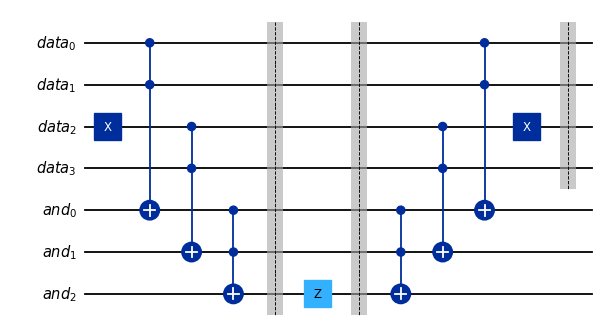

Dynamic MCZ Grover oracle


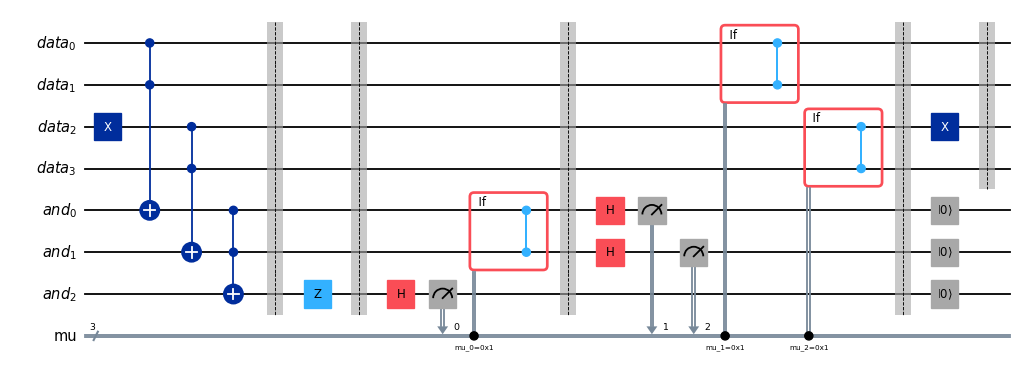

In [34]:
ORACLE_DRAW_MARKED_STATES = ["1011"]

unitary_oracle_circuit = unitary_grover_oracle(ORACLE_DRAW_MARKED_STATES)
dynamic_oracle_circuit = grover_oracle(ORACLE_DRAW_MARKED_STATES)

print("Unitary MCZ Grover oracle")
display(
    unitary_oracle_circuit.draw(
        "mpl", fold=-1, scale=0.65, idle_wires=False
    )
)

print("Dynamic MCZ Grover oracle")
display(
    dynamic_oracle_circuit.draw(
        "mpl", fold=-1, scale=0.65, idle_wires=False
    )
)

## Noise Model

This model adds depolarizing noise to active one- and two-qubit gates, a Pauli-X reset error, and symmetric readout error. `idle_error` is applied only to explicit `id` gates. Before simulation, the Grover circuit is transpiled into a CX-based basis so that the `two_qubit_error` also acts on decomposed CZ and CCX operations.

In [35]:
def make_noise_model(
    one_qubit_error=0.001,
    idle_error=0.001,
    two_qubit_error=0.01,
    reset_error=0.01,
    readout_error=0.01,
):
    noise_model = NoiseModel()

    error_1q = depolarizing_error(one_qubit_error, 1)
    error_idle = depolarizing_error(idle_error, 1)
    error_2q = depolarizing_error(two_qubit_error, 2)
    error_reset = pauli_error([
        ("X", reset_error),
        ("I", 1 - reset_error),
    ])
    error_readout = ReadoutError([
        [1 - readout_error, readout_error],
        [readout_error, 1 - readout_error],
    ])

    # Active single-qubit gate noise is independent of idle/storage noise.
    noise_model.add_all_qubit_quantum_error(
        error_1q,
        ["h", "x", "y", "z", "sdg"],
    )
    # Each explicit id gate represents one storage round.
    noise_model.add_all_qubit_quantum_error(error_idle, ["id"])
    noise_model.add_all_qubit_quantum_error(error_2q, ["cx"])
    noise_model.add_all_qubit_quantum_error(error_reset, ["reset"])
    noise_model.add_all_qubit_readout_error(error_readout)
    return noise_model


noise_model = make_noise_model()
noise_model

<NoiseModel on ['id', 'y', 'x', 'cx', 'z', 'reset', 'h', 'measure', 'sdg']>

## Compare Unitary and Dynamic Grover

Both implementations use the same marked states, Grover iteration count, shot count, noise model, and CX-based transpilation. The unitary version reverses every AND tree; the dynamic version instead uses measurement, feed-forward, and reset.

In [36]:
GROVER_MARKED_STATES = ["1011"]
GROVER_ITERATIONS = None  # None selects a near-optimal value automatically.
GROVER_SHOTS = DEFAULT_SHOTS

grover_circuits = {
    "unitary": build_unitary_grover_circuit(
        GROVER_MARKED_STATES,
        iterations=GROVER_ITERATIONS,
        add_barriers=True,
    ),
    "dynamic": build_dynamic_grover_circuit(
        GROVER_MARKED_STATES,
        iterations=GROVER_ITERATIONS,
        add_barriers=True,
    ),
}

simulator = AerSimulator(
    method="matrix_product_state",
    noise_model=noise_model,
    seed_simulator=SEED,
)

# CCX and CZ must be decomposed so their CX gates receive two_qubit_error.
noise_basis_gates = sorted(set(noise_model.basis_gates) | {"t", "tdg"})
transpiled_grover_circuits = {
    implementation: transpile(
        circuit,
        basis_gates=noise_basis_gates,
        optimization_level=0,
        seed_transpiler=SEED,
    )
    for implementation, circuit in grover_circuits.items()
}

comparison_rows = []
grover_counts_by_implementation = {}

for run_index, (implementation, circuit) in enumerate(
    transpiled_grover_circuits.items()
):
    result = simulator.run(
        circuit,
        shots=GROVER_SHOTS,
        seed_simulator=SEED + run_index,
    ).result()
    counts = register_counts(result.get_counts(0), circuit, "out")
    grover_counts_by_implementation[implementation] = counts

    success_probability = sum(
        counts.get(state, 0) for state in GROVER_MARKED_STATES
    ) / sum(counts.values())
    operation_counts = recursive_operation_counts(circuit)

    comparison_rows.append({
        "implementation": implementation,
        "iterations": grover_circuits[implementation].metadata["iterations"],
        "success_probability": success_probability,
        "num_qubits": circuit.num_qubits,
        "num_clbits": circuit.num_clbits,
        "logical_circuit_depth": grover_circuits[implementation].depth(),
        "cx": operation_counts.get("cx", 0),
        "h": operation_counts.get("h", 0),
        "measure": operation_counts.get("measure", 0),
        "reset": operation_counts.get("reset", 0),
        "if_else": operation_counts.get("if_else", 0),
    })

grover_comparison = pd.DataFrame(comparison_rows).set_index("implementation")
display(grover_comparison)

counts_comparison = (
    pd.DataFrame(grover_counts_by_implementation)
    .fillna(0)
    .astype(int)
)
counts_comparison = counts_comparison.loc[
    counts_comparison.max(axis=1).sort_values(ascending=False).index
]
display(counts_comparison)

,iterations,success_probability,num_qubits,num_clbits,logical_circuit_depth,cx,h,measure,reset,if_else
implementation,,,,,,,,,,
unitary,3,0.238281,7,4,50,216,100,4,0,0
dynamic,3,0.365234,7,7,74,126,118,22,18,18


,unitary,dynamic
1011,244,374
1001,78,65
1010,66,76
1111,71,72
0011,70,66
1000,57,50
0111,52,55
1110,52,35
0010,51,30
0000,47,25


## Qubit Sweep: 4 to 10 Data Qubits

This sweep compares unitary and dynamic Grover under the same noise model for 4–10 data qubits. Each size uses one alternating target (`1010...`) and an automatically selected Grover iteration count. Circuit depth is measured on the logical circuit before transpilation; 2Q depth and 2Q gate count are measured on the CX-basis transpiled circuit. Qiskit stores each `if_test` as an `if_else` operation internally. `GROVER_SWEEP_SHOTS` is separate from the single-size experiment because the 9- and 10-qubit circuits are substantially larger.

k= 4 unitary iterations= 3 success=0.2539
k= 4 dynamic iterations= 3 success=0.3906
k= 5 unitary iterations= 4 success=0.1133
k= 5 dynamic iterations= 4 success=0.2148
k= 6 unitary iterations= 6 success=0.0117
k= 6 dynamic iterations= 6 success=0.0547
k= 7 unitary iterations= 8 success=0.0195
k= 7 dynamic iterations= 8 success=0.0117


,num_qubits,target,implementation,iterations,shots,success_probability,total_qubits,circuit_depth,two_qubit_depth,two_qubit_gate_count,if_test_count,measure,reset
0,4,1010,unitary,3,256,0.253906,7,50,132,216,0,4,0
1,4,1010,dynamic,3,256,0.390625,7,74,72,126,18,22,18
2,5,10101,unitary,4,256,0.113281,9,82,248,384,0,5,0
3,5,10101,dynamic,4,256,0.214844,9,130,128,224,32,37,32
4,6,101010,unitary,6,256,0.011719,11,122,372,720,0,6,0
5,6,101010,dynamic,6,256,0.054688,11,194,192,420,60,66,60
6,7,1010101,unitary,8,256,0.019531,13,162,496,1152,0,7,0
7,7,1010101,dynamic,8,256,0.011719,13,258,256,672,96,103,96


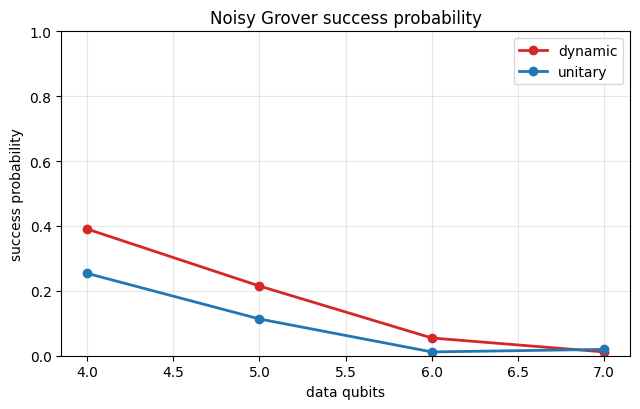

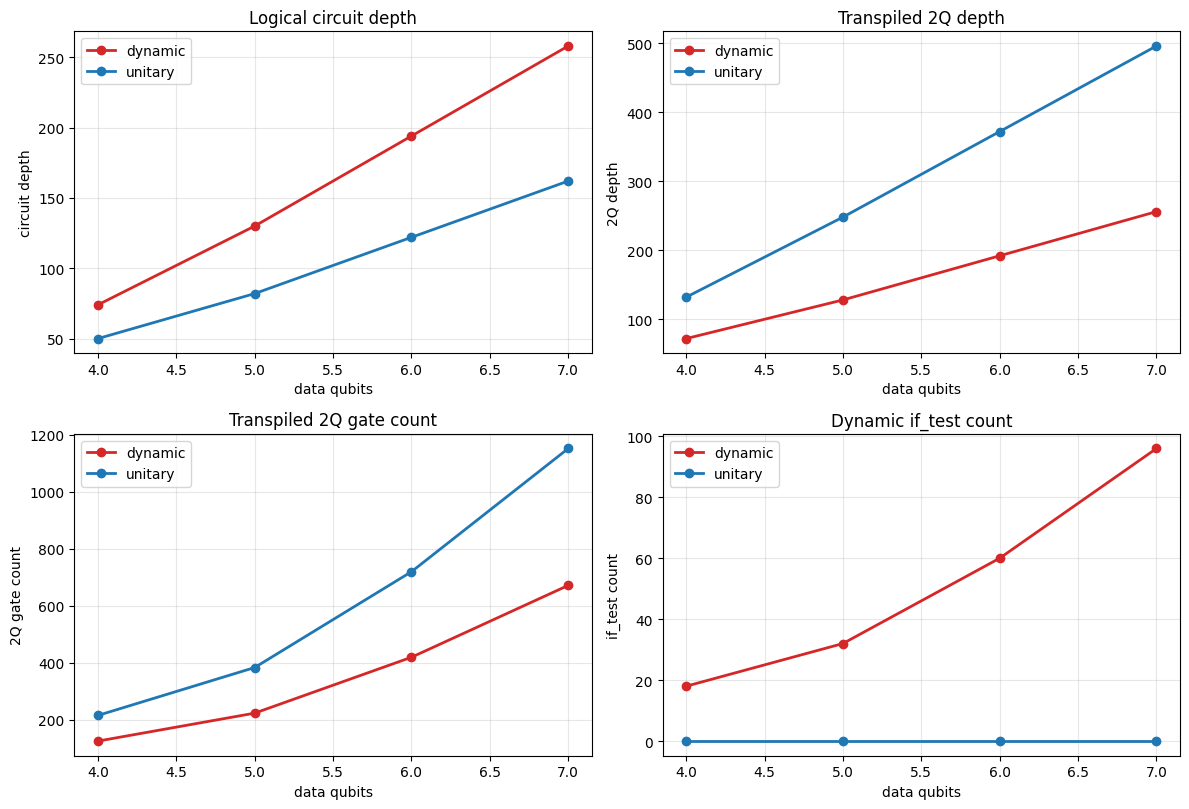

In [37]:
def alternating_target(num_qubits: int) -> str:
    """Return a target such as 1010, 10101, or 101010."""
    return ("10" * ((num_qubits + 1) // 2))[:num_qubits]


def run_grover_qubit_sweep(
    qubit_values=range(4, 11),
    shots: int = 256,
    seed: int = SEED,
) -> pd.DataFrame:
    """Run noisy unitary/dynamic Grover for each data-qubit count."""
    simulator = AerSimulator(
        method="matrix_product_state",
        noise_model=noise_model,
        seed_simulator=seed,
    )
    basis_gates = sorted(set(noise_model.basis_gates) | {"t", "tdg"})
    builders = {
        "unitary": build_unitary_grover_circuit,
        "dynamic": build_dynamic_grover_circuit,
    }
    rows = []

    for num_qubits in qubit_values:
        num_qubits = validate_num_controls(num_qubits)
        target = alternating_target(num_qubits)
        marked_states = [target]

        for implementation_index, (implementation, builder) in enumerate(
            builders.items()
        ):
            circuit = builder(
                marked_states,
                iterations=None,
                add_barriers=False,
            )
            transpiled_circuit = transpile(
                circuit,
                basis_gates=basis_gates,
                optimization_level=0,
                seed_transpiler=seed,
            )
            run_seed = seed + 2 * num_qubits + implementation_index
            result = simulator.run(
                transpiled_circuit,
                shots=shots,
                seed_simulator=run_seed,
            ).result()
            counts = register_counts(
                result.get_counts(0),
                transpiled_circuit,
                "out",
            )
            success_probability = counts.get(target, 0) / sum(counts.values())
            operation_counts = recursive_operation_counts(transpiled_circuit)

            rows.append({
                "num_qubits": num_qubits,
                "target": target,
                "implementation": implementation,
                "iterations": circuit.metadata["iterations"],
                "shots": shots,
                "success_probability": success_probability,
                "total_qubits": transpiled_circuit.num_qubits,
                "circuit_depth": circuit.depth(),
                "two_qubit_depth": two_qubit_depth(transpiled_circuit),
                "two_qubit_gate_count": two_qubit_gate_count(transpiled_circuit),
                "if_test_count": operation_counts.get("if_else", 0),
                "measure": operation_counts.get("measure", 0),
                "reset": operation_counts.get("reset", 0),
            })
            print(
                f"k={num_qubits:2d} {implementation:7s} "
                f"iterations={circuit.metadata['iterations']:2d} "
                f"success={success_probability:.4f}"
            )

    return pd.DataFrame(rows)


GROVER_SWEEP_QUBITS = range(4, 8)
GROVER_SWEEP_SHOTS = 256

grover_sweep_results = run_grover_qubit_sweep(
    qubit_values=GROVER_SWEEP_QUBITS,
    shots=GROVER_SWEEP_SHOTS,
)
display(grover_sweep_results)

implementation_colors = {
    "unitary": "tab:blue",
    "dynamic": "tab:red",
}

# Success probability: separate figure.
fig_success, ax_success = plt.subplots(figsize=(6.5, 4.2))
for implementation, group in grover_sweep_results.groupby("implementation"):
    ax_success.plot(
        group["num_qubits"],
        group["success_probability"],
        marker="o",
        linewidth=2,
        color=implementation_colors[implementation],
        label=implementation,
    )

ax_success.set_title("Noisy Grover success probability")
ax_success.set_xlabel("data qubits")
ax_success.set_ylabel("success probability")
ax_success.set_ylim(0, 1)
ax_success.grid(alpha=0.3)
ax_success.legend()
fig_success.tight_layout()
plt.show()

# Resource counts: four panels in one figure.
resource_metrics = [
    ("circuit_depth", "Logical circuit depth", "circuit depth"),
    ("two_qubit_depth", "Transpiled 2Q depth", "2Q depth"),
    ("two_qubit_gate_count", "Transpiled 2Q gate count", "2Q gate count"),
    ("if_test_count", "Dynamic if_test count", "if_test count"),
]
fig_resources, resource_axes = plt.subplots(2, 2, figsize=(12, 8.2))
resource_axes = resource_axes.ravel()

for axis, (column, title, ylabel) in zip(resource_axes, resource_metrics):
    for implementation, group in grover_sweep_results.groupby("implementation"):
        axis.plot(
            group["num_qubits"],
            group[column],
            marker="o",
            linewidth=2,
            color=implementation_colors[implementation],
            label=implementation,
        )
    axis.set_title(title)
    axis.set_xlabel("data qubits")
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.3)
    axis.legend()

fig_resources.tight_layout()
plt.show()